# 🌍 English → German Neural Machine Translation
## Seq2Seq + Bahdanau Attention + Beam Search

### 📋 Instructions:
1. **First time?** Run ALL cells from top to bottom (trains + saves the model)
2. **Already trained?** Skip to **Section 7: LOAD & INFERENCE** and run from there

---

## ⚙️ Section 0: Configuration

Change `MODE` to control behavior:
- `"train"` → trains the model from scratch and saves it
- `"inference"` → loads a previously saved model and goes straight to translation

In [1]:
# ============================================================
# ⭐ MAIN CONFIGURATION - CHANGE HERE ⭐
# ============================================================
MODE = "train"  # ← CAMBIAR AQUÍ: "train" or "inference"

# --- Hyperparameters (only matter for training) ---
EMBEDDING_DIM = 256       # ← CAMBIAR AQUÍ
UNITS = 512               # ← CAMBIAR AQUÍ
BATCH_SIZE = 64           # ← CAMBIAR AQUÍ
EPOCHS = 30               # ← CAMBIAR AQUÍ
NUM_EXAMPLES = 200000      # ← CAMBIAR AQUÍ (None = use all data)
BEAM_WIDTH = 5            # ← CAMBIAR AQUÍ

# --- Save/Load paths ---
import os
SAVE_DIR = "/content/drive/MyDrive/nmt_en_de_model"  # ← CAMBIAR AQUÍ
# If you don't use Google Drive, change to: SAVE_DIR = "/content/nmt_en_de_model"

print(f"Mode: {MODE}")
print(f"Save/Load directory: {SAVE_DIR}")

Mode: train
Save/Load directory: /content/drive/MyDrive/nmt_en_de_model


## 📁 Section 1: Mount Google Drive (for persistent storage)

In [2]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Drive mounted. Save directory: {SAVE_DIR}")

Mounted at /content/drive
✅ Drive mounted. Save directory: /content/drive/MyDrive/nmt_en_de_model


## 📦 Section 2: Imports & Setup

In [3]:
import tensorflow as tf
import numpy as np
import unicodedata
import re
import pickle
import json
import time
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📚 Section 3: Data Download & Preprocessing

In [4]:
import zipfile

# Define the local data directory
LOCAL_DATA_DIR = '/content/data'
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

# Path to the local zip file
path_to_zip = os.path.join(LOCAL_DATA_DIR, 'deu-eng.zip')
path_to_file = os.path.join(LOCAL_DATA_DIR, 'deu.txt')

# Check if the zip file exists locally
if not os.path.exists(path_to_zip):
    print(f"Warning: '{path_to_zip}' not found. Please upload the 'deu-eng.zip' file to the '{LOCAL_DATA_DIR}' directory.")
    # You might want to add a way to download it if it's not present
    # For now, we'll proceed assuming it will be uploaded manually
else:
    print(f"✅ Local dataset zip found: {path_to_zip}")

# Extract the zip file if deu.txt doesn't exist
if not os.path.exists(path_to_file):
    if os.path.exists(path_to_zip):
        print(f"Extracting '{path_to_zip}'...")
        with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
            zip_ref.extractall(LOCAL_DATA_DIR)
        print(f"✅ Dataset extracted to: {path_to_file}")
    else:
        print("Cannot extract dataset as zip file was not found.")
else:
    print(f"✅ Dataset text file already exists: {path_to_file}")


✅ Local dataset zip found: /content/data/deu-eng.zip
Extracting '/content/data/deu-eng.zip'...
✅ Dataset extracted to: /content/data/deu.txt


In [5]:
def unicode_to_ascii(s):
    """Normalize unicode characters to ASCII."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def preprocess_sentence(w):
    """Clean and tokenize a sentence."""
    w = unicode_to_ascii(w.lower().strip())
    # Add space between word and punctuation
    w = re.sub(r"([?.!,¡])", r" \1 ", w)
    w = re.sub(r'[" "]+', " ", w)
    # Keep only letters, punctuation, and spaces
    w = re.sub(r"[^a-zA-Zäöüß?.!,]+", " ", w)
    w = w.strip()
    # Add start/end tokens
    w = '<start> ' + w + ' <end>'
    return w

def create_dataset(path, num_examples=None):
    """Load and preprocess the parallel corpus."""
    lines = open(path, encoding='UTF-8').read().strip().split('\n')
    word_pairs = []
    for l in lines[:num_examples]:
        parts = l.split('\t')
        if len(parts) >= 2:
            en = preprocess_sentence(parts[0])
            de = preprocess_sentence(parts[1])
            word_pairs.append([en, de])
    return zip(*word_pairs)

def tokenize(lang):
    """Create tokenizer and return padded sequences."""
    lang_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
    lang_tokenizer.fit_on_texts(lang)
    tensor = lang_tokenizer.texts_to_sequences(lang)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')
    return tensor, lang_tokenizer

def load_dataset(path, num_examples=None):
    """Full pipeline: load, preprocess, tokenize."""
    targ_lang, inp_lang = create_dataset(path, num_examples)  # Note: file is DE\tEN
    # Wait - the file format is: English \t German \t Attribution
    # So parts[0] = English, parts[1] = German
    # We want EN->DE, so input=English, target=German
    input_tensor, inp_lang_tokenizer = tokenize(targ_lang)  # This is actually English
    target_tensor, targ_lang_tokenizer = tokenize(inp_lang)  # This is actually German
    return input_tensor, target_tensor, inp_lang_tokenizer, targ_lang_tokenizer

print("✅ Preprocessing functions defined")

✅ Preprocessing functions defined


In [6]:
# Load and preprocess data
en, de = create_dataset(path_to_file, NUM_EXAMPLES)
en = list(en)
de = list(de)

print(f"Total sentence pairs: {len(en)}")
print(f"\nExample pairs:")
for i in range(5):
    print(f"  EN: {en[i]}")
    print(f"  DE: {de[i]}")
    print()

Total sentence pairs: 200000

Example pairs:
  EN: <start> go . <end>
  DE: <start> geh . <end>

  EN: <start> hi . <end>
  DE: <start> hallo ! <end>

  EN: <start> hi . <end>
  DE: <start> gruß gott ! <end>

  EN: <start> run ! <end>
  DE: <start> lauf ! <end>

  EN: <start> run . <end>
  DE: <start> lauf ! <end>



In [7]:
# Tokenize
# EN is input (source), DE is target
input_tensor, inp_lang = tokenize(en)
target_tensor, targ_lang = tokenize(de)

max_length_inp = input_tensor.shape[1]
max_length_targ = target_tensor.shape[1]

vocab_inp_size = len(inp_lang.word_index) + 1
vocab_tar_size = len(targ_lang.word_index) + 1

print(f"Input (EN) tensor shape: {input_tensor.shape}")
print(f"Target (DE) tensor shape: {target_tensor.shape}")
print(f"EN vocabulary size: {vocab_inp_size}")
print(f"DE vocabulary size: {vocab_tar_size}")
print(f"Max EN sequence length: {max_length_inp}")
print(f"Max DE sequence length: {max_length_targ}")

Input (EN) tensor shape: (200000, 14)
Target (DE) tensor shape: (200000, 23)
EN vocabulary size: 12183
DE vocabulary size: 24228
Max EN sequence length: 14
Max DE sequence length: 23


In [8]:
# Train/Val split
from sklearn.model_selection import train_test_split

input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(
    input_tensor, target_tensor, test_size=0.2, random_state=42
)

print(f"Training samples: {len(input_tensor_train)}")
print(f"Validation samples: {len(input_tensor_val)}")

# Create tf.data.Dataset
BUFFER_SIZE = len(input_tensor_train)
steps_per_epoch = len(input_tensor_train) // BATCH_SIZE

dataset = tf.data.Dataset.from_tensor_slices(
    (input_tensor_train, target_tensor_train)
).shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (input_tensor_val, target_tensor_val)
).batch(BATCH_SIZE, drop_remainder=True)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Batch size: {BATCH_SIZE}")

Training samples: 160000
Validation samples: 40000
Steps per epoch: 2500
Batch size: 64


## 🧠 Section 4: Model Architecture (Encoder + Attention + Decoder)

In [9]:
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super(Encoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(
            self.enc_units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer='glorot_uniform'
        )

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.gru(x, initial_state=hidden)
        return output, state

    def initialize_hidden_state(self, batch_size=None):
        bs = batch_size if batch_size is not None else self.batch_sz
        return tf.zeros((bs, self.enc_units))


class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        # query: (batch, hidden_size) -> (batch, 1, hidden_size)
        query_with_time_axis = tf.expand_dims(query, 1)
        # score: (batch, max_length, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        # attention_weights: (batch, max_length, 1)
        attention_weights = tf.nn.softmax(score, axis=1)
        # context_vector: (batch, hidden_size)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights


class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
        super(Decoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(
            self.dec_units,
            return_sequences=True,
            return_state=True,
            recurrent_initializer='glorot_uniform'
        )
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        # Concatenate context vector and embedding
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)
        output = tf.reshape(output, (-1, output.shape[2]))
        x = self.fc(output)
        return x, state, attention_weights


print("✅ Model classes defined (Encoder + BahdanauAttention + Decoder)")

✅ Model classes defined (Encoder + BahdanauAttention + Decoder)


In [10]:
# Instantiate the model
encoder = Encoder(vocab_inp_size, EMBEDDING_DIM, UNITS, BATCH_SIZE)
decoder = Decoder(vocab_tar_size, EMBEDDING_DIM, UNITS, BATCH_SIZE)

# Optimizer & Loss
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none'
)

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

print("✅ Encoder and Decoder instantiated")
print(f"   Encoder: vocab={vocab_inp_size}, emb={EMBEDDING_DIM}, units={UNITS}")
print(f"   Decoder: vocab={vocab_tar_size}, emb={EMBEDDING_DIM}, units={UNITS}")

✅ Encoder and Decoder instantiated
   Encoder: vocab=12183, emb=256, units=512
   Decoder: vocab=24228, emb=256, units=512


## 🏋️ Section 5: Training

In [11]:
@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0
    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden)
        dec_hidden = enc_hidden
        dec_input = tf.expand_dims([targ_lang.word_index['<start>']] * BATCH_SIZE, 1)

        # Teacher forcing
        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)  # Teacher forcing

    batch_loss = (loss / int(targ.shape[1]))
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    # Gradient clipping
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    optimizer.apply_gradients(zip(gradients, variables))
    return batch_loss

print("✅ Training step function defined")

✅ Training step function defined


In [12]:
if MODE == "train":
    print("="*60)
    print("🚀 STARTING TRAINING")
    print("="*60)
    print(f"Epochs: {EPOCHS} | Batch Size: {BATCH_SIZE} | Steps/epoch: {steps_per_epoch}")
    print()

    history = {'loss': []}

    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        enc_hidden = encoder.initialize_hidden_state()
        total_loss = 0

        for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
            batch_loss = train_step(inp, targ, enc_hidden)
            total_loss += batch_loss

            if batch % 100 == 0:
                print(f'  Epoch {epoch} Batch {batch} Loss {batch_loss.numpy():.4f}')

        avg_loss = total_loss / steps_per_epoch
        history['loss'].append(avg_loss.numpy())
        elapsed = time.time() - start
        print(f'Epoch {epoch}/{EPOCHS} - Loss: {avg_loss:.4f} - Time: {elapsed:.1f}s')
        print()

    print("✅ Training complete!")
else:
    print("⏭️ Skipping training (MODE = 'inference'). Jump to Section 7.")

🚀 STARTING TRAINING
Epochs: 30 | Batch Size: 64 | Steps/epoch: 2500

  Epoch 1 Batch 0 Loss 3.2164
  Epoch 1 Batch 100 Loss 1.6019
  Epoch 1 Batch 200 Loss 1.5491
  Epoch 1 Batch 300 Loss 1.4964
  Epoch 1 Batch 400 Loss 1.4232
  Epoch 1 Batch 500 Loss 1.3128
  Epoch 1 Batch 600 Loss 1.3088
  Epoch 1 Batch 700 Loss 1.2585
  Epoch 1 Batch 800 Loss 1.1705
  Epoch 1 Batch 900 Loss 1.2112
  Epoch 1 Batch 1000 Loss 1.1675
  Epoch 1 Batch 1100 Loss 1.0431
  Epoch 1 Batch 1200 Loss 1.0221
  Epoch 1 Batch 1300 Loss 1.0237
  Epoch 1 Batch 1400 Loss 1.0780
  Epoch 1 Batch 1500 Loss 0.9257
  Epoch 1 Batch 1600 Loss 0.9289
  Epoch 1 Batch 1700 Loss 1.0188
  Epoch 1 Batch 1800 Loss 1.0284
  Epoch 1 Batch 1900 Loss 0.9577
  Epoch 1 Batch 2000 Loss 0.8967
  Epoch 1 Batch 2100 Loss 0.8018
  Epoch 1 Batch 2200 Loss 0.6952
  Epoch 1 Batch 2300 Loss 0.8706
  Epoch 1 Batch 2400 Loss 0.7433
Epoch 1/30 - Loss: 1.0995 - Time: 388.5s

  Epoch 2 Batch 0 Loss 0.6829
  Epoch 2 Batch 100 Loss 0.7775
  Epoch 2 Batc

## 💾 Section 6: SAVE MODEL

Saves everything needed to reload the model without retraining:
- Encoder & Decoder weights
- Tokenizers (vocabularies)
- Hyperparameters & sequence lengths

In [13]:
def save_model(save_dir, encoder, decoder, inp_lang, targ_lang, config):
    """Save the full model state to disk."""
    os.makedirs(save_dir, exist_ok=True)

    # 1. Save weights
    encoder.save_weights(os.path.join(save_dir, 'encoder_weights.weights.h5'))
    decoder.save_weights(os.path.join(save_dir, 'decoder_weights.weights.h5'))
    print("✅ Weights saved")

    # 2. Save tokenizers
    with open(os.path.join(save_dir, 'inp_tokenizer.pkl'), 'wb') as f:
        pickle.dump(inp_lang, f)
    with open(os.path.join(save_dir, 'targ_tokenizer.pkl'), 'wb') as f:
        pickle.dump(targ_lang, f)
    print("✅ Tokenizers saved")

    # 3. Save config (hyperparameters + dimensions)
    with open(os.path.join(save_dir, 'config.json'), 'w') as f:
        json.dump(config, f, indent=2)
    print("✅ Config saved")

    print(f"\n🎉 Model fully saved to: {save_dir}")
    print(f"   Files: {os.listdir(save_dir)}")


if MODE == "train":
    config = {
        'embedding_dim': EMBEDDING_DIM,
        'units': UNITS,
        'batch_size': BATCH_SIZE,
        'vocab_inp_size': vocab_inp_size,
        'vocab_tar_size': vocab_tar_size,
        'max_length_inp': int(max_length_inp),
        'max_length_targ': int(max_length_targ),
        'beam_width': BEAM_WIDTH,
        'epochs_trained': EPOCHS,
    }
    save_model(SAVE_DIR, encoder, decoder, inp_lang, targ_lang, config)
else:
    print("⏭️ Skipping save (MODE = 'inference').")

✅ Weights saved
✅ Tokenizers saved
✅ Config saved

🎉 Model fully saved to: /content/drive/MyDrive/nmt_en_de_model
   Files: ['config.json', 'inp_tokenizer.pkl', 'targ_tokenizer.pkl', 'encoder_weights.weights.h5', 'decoder_weights.weights.h5']


---
---

# 🚀 Section 7: LOAD & INFERENCE

## ⬇️ If you already have a trained model, START HERE ⬇️

Run the cells below to:
1. Reload the model from Google Drive
2. Translate English sentences to German interactively

---

In [14]:
# ============================================================
# LOAD MODEL - Run this cell to restore a saved model
# ============================================================

def load_model(save_dir):
    """Load the full model state from disk."""
    print(f"📥 Loading model from: {save_dir}")
    print(f"   Files found: {os.listdir(save_dir)}")

    # 1. Load config
    with open(os.path.join(save_dir, 'config.json'), 'r') as f:
        config = json.load(f)
    print(f"✅ Config loaded: {config}")

    # 2. Load tokenizers
    with open(os.path.join(save_dir, 'inp_tokenizer.pkl'), 'rb') as f:
        inp_lang_loaded = pickle.load(f)
    with open(os.path.join(save_dir, 'targ_tokenizer.pkl'), 'rb') as f:
        targ_lang_loaded = pickle.load(f)
    print("✅ Tokenizers loaded")

    # 3. Rebuild models with saved dimensions
    encoder_loaded = Encoder(
        config['vocab_inp_size'],
        config['embedding_dim'],
        config['units'],
        1  # batch_size=1 for inference
    )
    decoder_loaded = Decoder(
        config['vocab_tar_size'],
        config['embedding_dim'],
        config['units'],
        1  # batch_size=1 for inference
    )

    # 4. Build models by running dummy data through them
    dummy_input = tf.zeros((1, config['max_length_inp']), dtype=tf.int32)
    dummy_hidden = tf.zeros((1, config['units']))
    enc_out, enc_state = encoder_loaded(dummy_input, dummy_hidden)
    dummy_dec_input = tf.zeros((1, 1), dtype=tf.int32)
    _ = decoder_loaded(dummy_dec_input, enc_state, enc_out)

    # 5. Load weights
    encoder_loaded.load_weights(os.path.join(save_dir, 'encoder_weights.weights.h5'))
    decoder_loaded.load_weights(os.path.join(save_dir, 'decoder_weights.weights.h5'))
    print("✅ Weights loaded")

    print(f"\n🎉 Model restored successfully!")
    print(f"   Trained for {config['epochs_trained']} epochs")
    print(f"   EN vocab: {config['vocab_inp_size']} | DE vocab: {config['vocab_tar_size']}")

    return encoder_loaded, decoder_loaded, inp_lang_loaded, targ_lang_loaded, config


# --- Load the model ---
if MODE == "inference":
    # Need imports if starting fresh
    import tensorflow as tf
    import numpy as np
    import pickle
    import json
    import os
    import re
    import unicodedata

    # Mount drive if not already
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except:
        pass

    encoder, decoder, inp_lang, targ_lang, loaded_config = load_model(SAVE_DIR)
    max_length_inp = loaded_config['max_length_inp']
    max_length_targ = loaded_config['max_length_targ']
    UNITS = loaded_config['units']
    BEAM_WIDTH = loaded_config.get('beam_width', 5)
else:
    print("✅ Using model from training (already in memory).")
    # Model is already in encoder/decoder variables from training

✅ Using model from training (already in memory).


## 🔍 Section 8: Translation Functions (Greedy + Beam Search)

In [15]:
def preprocess_input_sentence(sentence):
    """Preprocess a raw English sentence for the model."""
    sentence = unicode_to_ascii(sentence.lower().strip())
    sentence = re.sub(r"([?.!,¡])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    sentence = sentence.strip()
    sentence = '<start> ' + sentence + ' <end>'
    return sentence


def sentence_to_tensor(sentence, tokenizer, max_length):
    """Convert a preprocessed sentence to a padded tensor."""
    tokens = []
    for word in sentence.split(' '):
        if word in tokenizer.word_index:
            tokens.append(tokenizer.word_index[word])
        # Skip unknown words (OOV)
    # Pad to max_length
    tokens = tokens[:max_length]  # Truncate if too long
    tokens = tokens + [0] * (max_length - len(tokens))  # Pad
    return tf.constant([tokens], dtype=tf.int32)


def greedy_translate(sentence):
    """Translate using greedy decoding."""
    preprocessed = preprocess_input_sentence(sentence)
    input_tensor = sentence_to_tensor(preprocessed, inp_lang, max_length_inp)

    result = []
    hidden = tf.zeros((1, UNITS))
    enc_out, enc_hidden = encoder(input_tensor, hidden)

    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([targ_lang.word_index['<start>']], 0)

    for t in range(max_length_targ):
        predictions, dec_hidden, attention_weights = decoder(dec_input, dec_hidden, enc_out)
        predicted_id = tf.argmax(predictions[0]).numpy()

        if targ_lang.index_word.get(predicted_id, '') == '<end>':
            break
        if predicted_id != 0:
            result.append(targ_lang.index_word.get(predicted_id, ''))

        dec_input = tf.expand_dims([predicted_id], 0)

    return ' '.join(result)


def beam_search_translate(sentence, beam_width=None):
    """Translate using beam search decoding."""
    if beam_width is None:
        beam_width = BEAM_WIDTH

    preprocessed = preprocess_input_sentence(sentence)
    input_tensor = sentence_to_tensor(preprocessed, inp_lang, max_length_inp)

    hidden = tf.zeros((1, UNITS))
    enc_out, enc_hidden = encoder(input_tensor, hidden)

    start_token = targ_lang.word_index['<start>']
    end_token = targ_lang.word_index.get('<end>', 0)

    # Each beam: (log_probability, [token_ids], decoder_hidden_state)
    beams = [(0.0, [start_token], enc_hidden)]
    completed = []

    for t in range(max_length_targ):
        all_candidates = []

        for log_prob, seq, dec_hidden in beams:
            last_token = seq[-1]

            # If this beam already ended, keep it
            if last_token == end_token:
                completed.append((log_prob, seq, dec_hidden))
                continue

            dec_input = tf.expand_dims([last_token], 0)
            predictions, new_hidden, _ = decoder(dec_input, dec_hidden, enc_out)

            # Get log probabilities
            log_probs = tf.nn.log_softmax(predictions[0]).numpy()

            # Get top-k candidates
            top_k_indices = np.argsort(log_probs)[-beam_width:]

            for idx in top_k_indices:
                new_log_prob = log_prob + log_probs[idx]
                new_seq = seq + [idx]
                all_candidates.append((new_log_prob, new_seq, new_hidden))

        if not all_candidates:
            break

        # Select top beams
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = all_candidates[:beam_width]

        # Early stop if all beams have ended
        if all(b[1][-1] == end_token for b in beams):
            completed.extend(beams)
            break

    # If no beam completed, use the best active beam
    if not completed:
        completed = beams

    # Pick best completed beam (length-normalized)
    best = max(completed, key=lambda x: x[0] / max(len(x[1]), 1))
    tokens = best[1]

    # Convert token IDs to words
    result = []
    for tok_id in tokens:
        word = targ_lang.index_word.get(tok_id, '')
        if word == '<end>':
            break
        if word and word != '<start>':
            result.append(word)

    return ' '.join(result)


print("✅ Translation functions defined (greedy + beam search)")

✅ Translation functions defined (greedy + beam search)


## 🎯 Section 9: Quick Test

In [16]:
# Quick test translations
test_sentences = [
    "Hello, how are you?",
    "I love you.",
    "Where is the train station?",
    "The weather is nice today.",
    "Can you help me?",
    "I am a student.",
    "Thank you very much.",
    "What is your name?",
]

print("=" * 70)
print("🎯 TRANSLATION TEST")
print("=" * 70)
for sent in test_sentences:
    greedy_result = greedy_translate(sent)
    beam_result = beam_search_translate(sent)
    print(f"\n🇬🇧 EN:     {sent}")
    print(f"🇩🇪 Greedy: {greedy_result}")
    print(f"🇩🇪 Beam:   {beam_result}")

🎯 TRANSLATION TEST

🇬🇧 EN:     Hello, how are you?
🇩🇪 Greedy: hallo , wie geht es euch ?
🇩🇪 Beam:   hallo , wie geht es euch ?

🇬🇧 EN:     I love you.
🇩🇪 Greedy: ich liebe dich .
🇩🇪 Beam:   ich liebe dich .

🇬🇧 EN:     Where is the train station?
🇩🇪 Greedy: wo ist der bahnhof ?
🇩🇪 Beam:   wo ist der bahnhof ?

🇬🇧 EN:     The weather is nice today.
🇩🇪 Greedy: heute ist ein schones wetter .
🇩🇪 Beam:   heute ist ein schones wetter .

🇬🇧 EN:     Can you help me?
🇩🇪 Greedy: kannst du mir helfen ?
🇩🇪 Beam:   kannst du mir helfen ?

🇬🇧 EN:     I am a student.
🇩🇪 Greedy: ich bin ein schuler .
🇩🇪 Beam:   ich bin ein schuler .

🇬🇧 EN:     Thank you very much.
🇩🇪 Greedy: vielen dank !
🇩🇪 Beam:   vielen dank !

🇬🇧 EN:     What is your name?
🇩🇪 Greedy: wie heißt dein name ?
🇩🇪 Beam:   wie heißt dein name ?


## 💬 Section 10: Interactive Translator

Write any English sentence and get the German translation!

In [17]:
# ============================================================
# 💬 INTERACTIVE TRANSLATOR
# Type English sentences and get German translations!
# Type 'quit' or 'exit' to stop
# ============================================================

print("=" * 60)
print("🌍 ENGLISH → GERMAN INTERACTIVE TRANSLATOR")
print("=" * 60)
print("Type an English sentence and press Enter.")
print("Type 'quit' or 'exit' to stop.")
print("=" * 60)

while True:
    try:
        sentence = input("\n🇬🇧 English: ").strip()
    except EOFError:
        break

    if not sentence:
        continue
    if sentence.lower() in ['quit', 'exit', 'q']:
        print("\n👋 Auf Wiedersehen!")
        break

    # Translate with both methods
    greedy_result = greedy_translate(sentence)
    beam_result = beam_search_translate(sentence)

    print(f"🇩🇪 Greedy:      {greedy_result}")
    print(f"🇩🇪 Beam Search: {beam_result}")

🌍 ENGLISH → GERMAN INTERACTIVE TRANSLATOR
Type an English sentence and press Enter.
Type 'quit' or 'exit' to stop.

🇬🇧 English: where did he run?
🇩🇪 Greedy:      wo ist er ?
🇩🇪 Beam Search: wo ist er ?

🇬🇧 English: i like cake
🇩🇪 Greedy:      ich mag kuchen zusammen .
🇩🇪 Beam Search: ich mag kuchen zusammen .

🇬🇧 English: tell me a story
🇩🇪 Greedy:      erzahle mir ein geschichtchen .
🇩🇪 Beam Search: erzahle mir ein geschichtchen .

🇬🇧 English: were you there last night?
🇩🇪 Greedy:      warst du gestern abend da ?
🇩🇪 Beam Search: warst du gestern abend da ?

🇬🇧 English: quit

👋 Auf Wiedersehen!


## 💬 Section 11: Single Sentence Translation (Alternative)

If the interactive loop doesn't work well in your environment, use this cell instead.
Just change the sentence and re-run the cell.

In [18]:
# ============================================================
# SINGLE SENTENCE TRANSLATION
# Change the sentence below and re-run this cell
# ============================================================

sentence = "I want to go to the park"  # ← CAMBIAR AQUÍ

print(f"🇬🇧 English:     {sentence}")
print(f"🇩🇪 Greedy:      {greedy_translate(sentence)}")
print(f"🇩🇪 Beam Search: {beam_search_translate(sentence)}")

🇬🇧 English:     I want to go to the park
🇩🇪 Greedy:      ich will in den park gehen .
🇩🇪 Beam Search: ich will in den park gehen .


## 📊 Section 12: Training Visualization (optional)

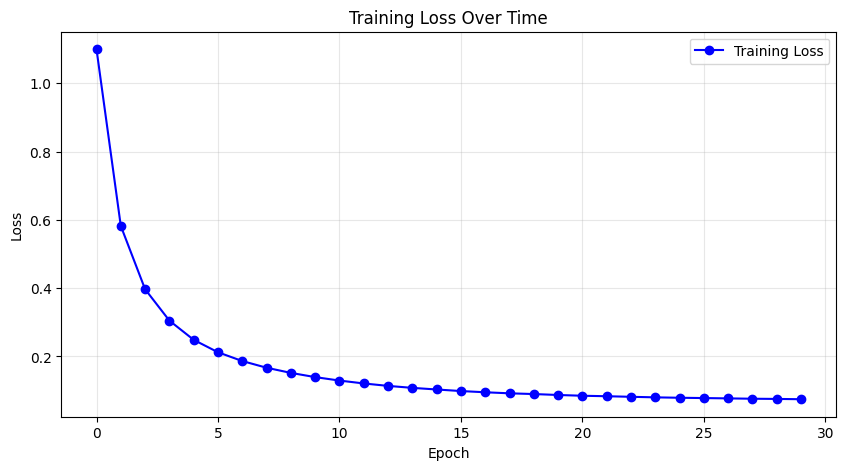

In [19]:
if MODE == "train" and 'history' in dir():
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.plot(history['loss'], 'b-o', label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No training history available (loaded from checkpoint).")

## 📚 Section 13: Batch Translation from File (optional)

Upload a `.txt` file with one English sentence per line.

In [21]:
def translate_file(input_path, output_path=None, use_beam=True):
    """Translate all sentences in a text file."""
    with open(input_path, 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f if line.strip()]

    print(f"Translating {len(sentences)} sentences...")
    results = []

    for i, sent in enumerate(sentences):
        if use_beam:
            translation = beam_search_translate(sent)
        else:
            translation = greedy_translate(sent)
        results.append((sent, translation))
        if (i + 1) % 10 == 0:
            print(f"  Translated {i+1}/{len(sentences)}")

    # Save results
    if output_path is None:
        output_path = input_path.replace('.txt', '_translated.txt')

    with open(output_path, 'w', encoding='utf-8') as f:
        for en, de in results:
            f.write(f"EN: {en}\n")
            f.write(f"DE: {de}\n\n")

    print(f"\n✅ Translations saved to: {output_path}")
    return results


# Example usage (uncomment to use):
results = translate_file('/content/my_sentences.txt')
print("✅ Batch translation function ready. Uncomment the line above to use.")

Translating 13 sentences...
  Translated 10/13

✅ Translations saved to: /content/my_sentences_translated.txt
✅ Batch translation function ready. Uncomment the line above to use.
